In [1]:
# Install required packages
!pip install kagglehub -q >nul 2>&1
%pip install scikit-learn pandas numpy matplotlib seaborn -q >nul 2>&1

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,  f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from collections import Counter

In [2]:
# Load the latest version of the dataset directly into a pandas DataFrame
file_path = r"C:\Users\mail2\OneDrive\Desktop\MY_DRIVE\MLOps\MLOps-Addy\Data_Sets\recruitment_data.csv"
dataset = pd.read_csv(file_path)
dataset.head(10)


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0
5,27,0,3,14,4,31.706659,54,50,50,1,1
6,48,0,2,6,1,17.291229,24,52,64,3,0
7,40,0,4,13,3,10.586811,6,3,92,3,0
8,26,1,3,6,5,28.774864,80,78,51,1,1
9,45,1,2,2,5,30.195964,92,16,94,3,0


In [3]:
# Basic dataset information
dataset.shape
dataset.info()
dataset.columns
dataset.describe()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   int64  
 1   Gender               1500 non-null   int64  
 2   EducationLevel       1500 non-null   int64  
 3   ExperienceYears      1500 non-null   int64  
 4   PreviousCompanies    1500 non-null   int64  
 5   DistanceFromCompany  1500 non-null   float64
 6   InterviewScore       1500 non-null   int64  
 7   SkillScore           1500 non-null   int64  
 8   PersonalityScore     1500 non-null   int64  
 9   RecruitmentStrategy  1500 non-null   int64  
 10  HiringDecision       1500 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 129.0 KB


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.148667,0.492000,2.188000,7.694000,3.00200,25.505379,50.564000,51.116000,49.387333,1.893333,0.310000
std,9.252728,0.500103,0.862449,4.641414,1.41067,14.567151,28.626215,29.353563,29.353201,0.689642,0.462647
min,20.000000,0.000000,1.000000,0.000000,1.00000,1.031376,0.000000,0.000000,0.000000,1.000000,0.000000
25%,27.000000,0.000000,2.000000,4.000000,2.00000,12.838851,25.000000,25.750000,23.000000,1.000000,0.000000
50%,35.000000,0.000000,2.000000,8.000000,3.00000,25.502239,52.000000,53.000000,49.000000,2.000000,0.000000
75%,43.000000,1.000000,3.000000,12.000000,4.00000,37.737996,75.000000,76.000000,76.000000,2.000000,1.000000
max,50.000000,1.000000,4.000000,15.000000,5.00000,50.992462,100.000000,100.000000,100.000000,3.000000,1.000000


In [ ]:
# Identify categorical, integer, and float columns
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:",len(object_cols))

int_ = (dataset.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:",len(num_cols))

fl = (dataset.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:",len(fl_cols))

Categorical variables: 0
Integer variables: 10
Float variables: 1


In [ ]:
# Check for missing/null values
dataset.isnull().sum()

Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

In [ ]:
# Remove duplicates and print if any duplicates were found
print("Duplicates:", dataset.duplicated().sum())

Duplicates: 0


In [ ]:
# Remove duplicates
dataset.drop_duplicates()
print("Duplicates:", dataset.duplicated().sum())

Duplicates: 0


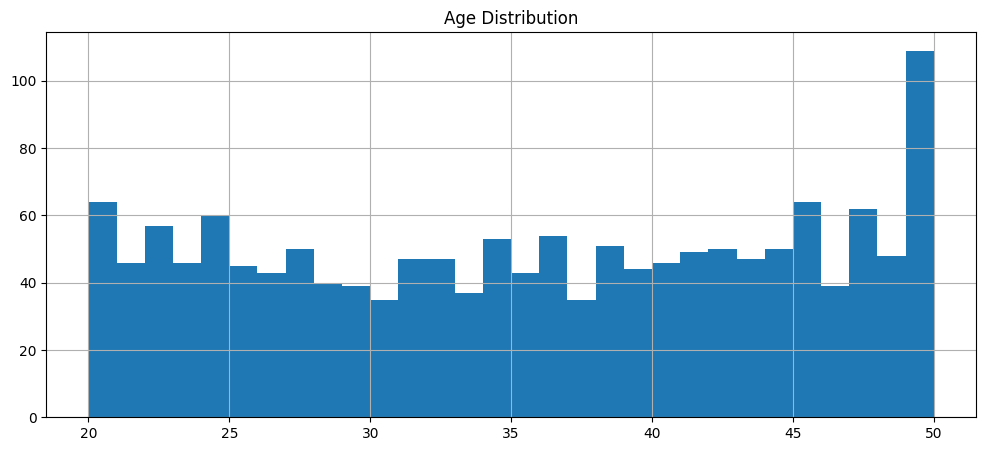

In [9]:
plt.figure(figsize=(12,5))
dataset['Age'].hist(bins=30)
plt.title("Age Distribution")
plt.show()

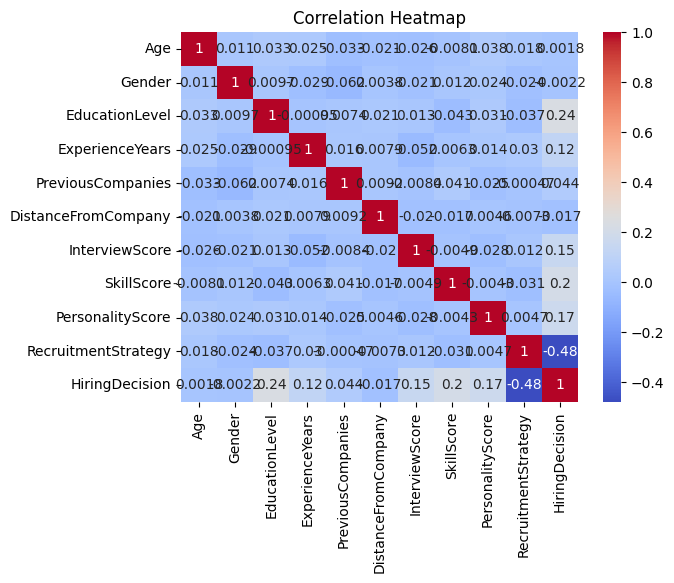

In [13]:
# Correlation Heatmap
numeric_dataset = dataset.select_dtypes(include=[np.number])
sns.heatmap(numeric_dataset.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [7]:
# Prepare feature matrix X and target vector y
target_column = 'HiringDecision'
X=dataset.drop(columns=[target_column])
y=dataset[target_column]

# Split into training and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
# Train a Random Forest Classifier
rf=RandomForestClassifier(random_state=42)
rf.fit(X,y)
y_pred=rf.predict(X)
accuracy=accuracy_score(y,y_pred)
print(f"Accuracy: {accuracy:.2f}")



Accuracy: 1.00


In [8]:
# To identify and select the most important features
rf.feature_importances_

array([0.05061664, 0.01147345, 0.08782225, 0.09047977, 0.02430364,
       0.06843961, 0.11857152, 0.12244627, 0.11172839, 0.31411844])

In [9]:
# To identify and select the most important features
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
selected_features = importances.head(10).index.tolist()
print("Selected Features:", selected_features)
X_selected = dataset[selected_features]

RecruitmentStrategy    0.314118
SkillScore             0.122446
InterviewScore         0.118572
PersonalityScore       0.111728
ExperienceYears        0.090480
EducationLevel         0.087822
DistanceFromCompany    0.068440
Age                    0.050617
PreviousCompanies      0.024304
Gender                 0.011473
dtype: float64
Selected Features: ['RecruitmentStrategy', 'SkillScore', 'InterviewScore', 'PersonalityScore', 'ExperienceYears', 'EducationLevel', 'DistanceFromCompany', 'Age', 'PreviousCompanies', 'Gender']


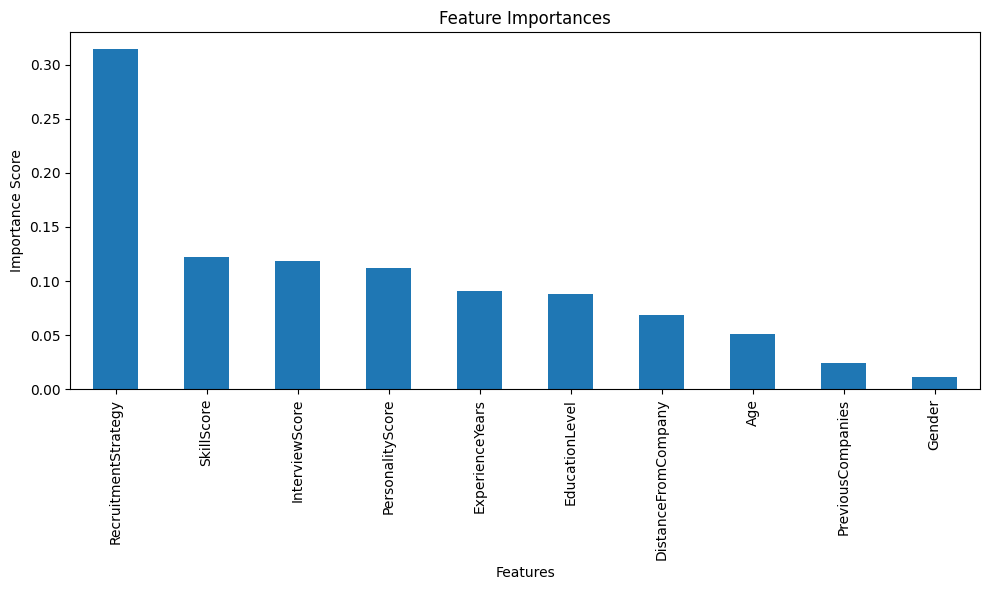

In [10]:
# Visualize Feature Importances
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [11]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


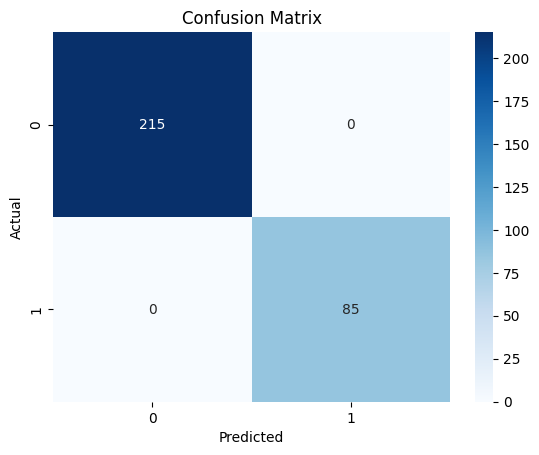

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# Hyperparameter Tuning - Cross Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X_train, y_train, cv=5)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())


Cross-validation scores: [0.91666667 0.9125     0.92916667 0.925      0.8875    ]
Mean cross-validation score: 0.9141666666666668


In [19]:
# Hyperparameter Tuning using GridSearchCV - Fitting 3 folds for each of 72 candidates, totalling 216 fits
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3,scoring='accuracy' ,n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)
best_rf = grid_search.best_estimator_
print("Test Set Accuracy:", best_rf.score(X_test, y_test))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-validation Score: 0.9216666666666667
Test Set Accuracy: 0.94


In [ ]:
# Hyperparameter Tuning using GridSearchCV - Fitting 5 folds for each of 72 candidates, totalling 360 fits
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5,scoring='accuracy' ,n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)
best_rf = grid_search.best_estimator_
print("Test Set Accuracy:", best_rf.score(X_test, y_test))

Fitting 15 folds for each of 72 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-validation Score: 0.9458333333333334
Test Set Accuracy: 0.9433333333333334
